# Intra-City Learning module


### Imports


In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"

In [6]:
import sys
sys.path.append(os.path.expanduser("~/websites/mapedia"))

In [7]:
# Imports 
import numpy as np
import pandas as pd
from pympler import asizeof

from modules import DBHandler

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv

import os

In [8]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = 'cpu'
print("Device:", device)

print(torch.cuda.is_available())
print(torch.__version__)
print(torch.version.cuda)
print(torch.backends.cuda.is_built())

Device: cuda
True
2.5.1
11.8
True


In [11]:
SAVE_FOLDER = '../data/raw_data/'
city = 'jakarta'
import geopandas as gpd
parquet_filename = SAVE_FOLDER + f"{city}_edges.parquet"
edges = gpd.read_parquet(parquet_filename)

numpy_filename = SAVE_FOLDER + f"{city}_speed_matrix.npy"
speed_matrix = np.load(numpy_filename)

In [12]:
print('Number of OSM ids: ', len(edges.osm_id.unique()))

null_counts = edges.isnull().sum()
availability = (1 - edges.isnull().mean()) * 100

summary = pd.DataFrame({
    "null_count": null_counts,
    "availability": availability
})

print("After merge summary:")
print(summary)
print("Column types:")
print(edges.info())

Number of OSM ids:  284477
After merge summary:
           null_count  availability
source              0    100.000000
target              0    100.000000
pgr_id              0    100.000000
osm_id              0    100.000000
oneway          45193     91.190294
road_type         585     99.885963
nlanes          45576     91.115634
width           51037     90.051093
length              0    100.000000
geometry            0    100.000000
max_speed      503831      1.785606
min_speed      511710      0.249712
Column types:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 512991 entries, 0 to 512990
Data columns (total 12 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   source     512991 non-null  int64   
 1   target     512991 non-null  int64   
 2   pgr_id     512991 non-null  int64   
 3   osm_id     512991 non-null  int64   
 4   oneway     467798 non-null  float64 
 5   road_type  512406 non-null  float64 
 6   nlanes    

In [14]:
# Original shape: (452533, 4, 7, 24)
# axes:            roads, seasons, days, hours

# ── 1. Remove seasons: average across seasons (axis=1) ──────────────────
# Shape: (452533, 7, 24)
avg_across_seasons = np.nanmean(speed_matrix, axis=1)
print('', avg_across_seasons.shape)

# ── 2. Split days into weekdays (0-4) and weekends (5-6) ────────────────
weekdays = avg_across_seasons[:, :5, :]   # (452533, 5, 24)
print('weekdays', weekdays.shape)
weekends = avg_across_seasons[:, 5:, :]   # (452533, 2, 24)
print('weekends', weekends.shape)

# Average each group → shape: (452533, 24)
avg_weekdays = np.nanmean(weekdays, axis=1)
print('weekends', weekends.shape)
avg_weekends = np.nanmean(weekends, axis=1)
print('weekends', weekends.shape)

# ── 3. Split 24 hours into 6 periods of 4 hours each ────────────────────
# Periods: 00-04, 04-08, 08-12, 12-16, 16-20, 20-24
# Shape after reshape: (452533, 6, 4)
weekdays_by_period = avg_weekdays.reshape(-1, 6, 4)   # (452533, 6, 4)
print('weekdays_by_period', weekdays_by_period.shape)
weekends_by_period = avg_weekends.reshape(-1, 6, 4)   # (452533, 6, 4)
print('weekends_by_period', weekends_by_period.shape)

# Average each period → shape: (452533, 6)
avg_weekdays_periods = np.nanmean(weekdays_by_period, axis=2)
print('avg_weekdays_periods', avg_weekdays_periods.shape)
avg_weekends_periods = np.nanmean(weekends_by_period, axis=2)
print('avg_weekends_periods', avg_weekends_periods.shape)

print(avg_weekdays_periods.shape)  # (452533, 6)
print(avg_weekends_periods.shape)  # (452533, 6)

# ── Summary of period labels ─────────────────────────────────────────────
period_labels = ["00-04", "04-08", "08-12", "12-16", "16-20", "20-24"]

# Shape: (452533, 2, 6)  →  [road, weekday/weekend, period]
final = np.stack([avg_weekdays_periods, avg_weekends_periods], axis=1)
print(final.shape)  # (452533, 2, 6)

/tmp/ipykernel_1047413/3991660077.py:6: RuntimeWarning: Mean of empty slice
  avg_across_seasons = np.nanmean(speed_matrix, axis=1)


 (512991, 7, 24)
weekdays (512991, 5, 24)
weekends (512991, 2, 24)


/tmp/ipykernel_1047413/3991660077.py:16: RuntimeWarning: Mean of empty slice
  avg_weekdays = np.nanmean(weekdays, axis=1)


weekends (512991, 2, 24)


/tmp/ipykernel_1047413/3991660077.py:18: RuntimeWarning: Mean of empty slice
  avg_weekends = np.nanmean(weekends, axis=1)
/tmp/ipykernel_1047413/3991660077.py:30: RuntimeWarning: Mean of empty slice
  avg_weekdays_periods = np.nanmean(weekdays_by_period, axis=2)


weekends (512991, 2, 24)
weekdays_by_period (512991, 6, 4)
weekends_by_period (512991, 6, 4)
avg_weekdays_periods (512991, 6)
avg_weekends_periods (512991, 6)
(512991, 6)
(512991, 6)
(512991, 2, 6)


/tmp/ipykernel_1047413/3991660077.py:32: RuntimeWarning: Mean of empty slice
  avg_weekends_periods = np.nanmean(weekends_by_period, axis=2)


In [18]:
# remove the season column average across this dimension ignoring NaN
# split the days into weekends and weekdays and average each
# split the days into periods of six periods and average them

In [15]:
n_avail_entries = np.sum(~np.isnan(final))
n_entries = final.shape[0]*final.shape[1]*final.shape[2]
print(n_avail_entries)
print(n_entries)
print('availability: ', n_avail_entries/n_entries * 100)

876104
6155892
availability:  14.231958585368295


In [16]:
final.shape

(512991, 2, 6)

In [17]:
edges.columns

Index(['source', 'target', 'pgr_id', 'osm_id', 'oneway', 'road_type', 'nlanes',
       'width', 'length', 'geometry', 'max_speed', 'min_speed'],
      dtype='object')

In [18]:
keep_cols = ["source","target","pgr_id","osm_id","oneway","road_type","nlanes","width","length","geometry","max_speed","min_speed"]
missing = [c for c in keep_cols if c not in edges.columns]
if missing: raise ValueError(f"Missing expected columns after merge/clean: {missing}")

if edges.crs == "EPSG:4326":
    print("Already in EPSG:4326")
else:
    print("Not in EPSG:4326")

Already in EPSG:4326


In [19]:
def nlanes_to_class(s):
  return np.select(
        [s.isna(), s <= 1, s <= 2], #s <= 3, s <= 4, s <= 5],
        [-1, 0, 1],# 2, 3, 4],
        default=2 #5 # all other nlanes 6+ are in one class
    )
class ZScaler:
    """Z-score scaler that ignores NaN."""
    def __init__(self):
        self.mu = None
        self.sd = None

    def fit(self, x: np.ndarray):
        self.mu = np.nanmean(x)
        self.sd = np.nanstd(x) + 1e-8

    def transform(self, x: np.ndarray):
        return (x - self.mu) / self.sd

# additional value adjustment
edges.oneway = edges.oneway.replace({
    2.0: 1.0, # since opposite direction oneway is considered oneway as well
    3.0: pd.NA, # as alternative is not oneway not two-way
})


edges["nlanes_cls"] = nlanes_to_class(edges["nlanes"])
# TODO: need to take into account the classification of other variables like max_speed, oneway, min_speed and how they not having masked values in them
edges["oneway"] = edges["oneway"].astype("Float64")

edges.to_crs(epsg=3857, inplace=True)
        

In [20]:
edges.head()

,source,target,pgr_id,osm_id,oneway,road_type,nlanes,width,length,geometry,max_speed,min_speed,nlanes_cls
0,52860,7874,98,4705045,1.0,2.0,4.0,10.0,56.769815,"LINESTRING (1.19e+07 -6.88e+05, 1.19e+07 -6.88...",NaN,NaN,2
1,30445,87959,212,4705043,1.0,2.0,1.0,4.0,293.579384,"LINESTRING (1.19e+07 -6.88e+05, 1.19e+07 -6.88...",NaN,NaN,0
2,1359,102290,213,4705046,1.0,2.0,2.0,6.0,12.779379,"LINESTRING (1.19e+07 -6.88e+05, 1.19e+07 -6.88...",NaN,NaN,1
3,47817,58347,38783,4705046,1.0,2.0,2.0,6.0,76.590609,"LINESTRING (1.19e+07 -6.88e+05, 1.19e+07 -6.88...",NaN,NaN,1
4,7874,92444,47381,4705045,1.0,2.0,4.0,10.0,28.160970,"LINESTRING (1.19e+07 -6.88e+05, 1.19e+07 -6.88...",NaN,NaN,2


In [21]:
# TODO: Both tokens could have been converted into -1, -2 integers values without having to go through all of this
MASK_TOKEN = "__MASK__"
UNK_TOKEN = "__UNK__"

highway_vals = edges["road_type"].fillna(UNK_TOKEN).astype(str).values
unique_highways = sorted(pd.unique(highway_vals).tolist())

if UNK_TOKEN not in unique_highways:
    unique_highways.append(UNK_TOKEN)
unique_highways.append(MASK_TOKEN)

hwy2id = {h: i for i, h in enumerate(unique_highways)}
id2hwy = {i: h for h, i in hwy2id.items()}

edges["highway_id"] = pd.Series(highway_vals).map(hwy2id)
HIGHWAY_MASK_ID = hwy2id[MASK_TOKEN]

In [22]:
hwy2id

{'0.0': 0,
 '1.0': 1,
 '2.0': 2,
 '3.0': 3,
 '4.0': 4,
 '5.0': 5,
 '__UNK__': 6,
 '__MASK__': 7}

In [23]:
edges["highway_id"]

0         2
1         2
2         2
3         2
4         2
         ..
512986    3
512987    1
512988    0
512989    0
512990    1
Name: highway_id, Length: 512991, dtype: int64

In [24]:
# =========================
# 4) SPATIAL split — longitude-quantile bands (simple, contiguous, no leakage)
# =========================
N = len(edges)
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.85, 0.05, 0.1
SPLIT_AXIS = "lon"   # "lon" = cut along longitude (x), "lat" = along latitude (y)
SPLIT_AXIS = "lat"   # "lon" = cut along longitude (x), "lat" = along latitude (y)

centroids = edges.geometry.centroid
coord = (centroids.x if SPLIT_AXIS == "lon" else centroids.y).to_numpy()
order = np.argsort(coord, kind="stable")

In [25]:
order

array([215327, 163733, 397276, ..., 482587, 483353, 482588])

In [26]:
final.shape

(512991, 2, 6)

In [27]:


n_train = int(round(TRAIN_FRAC * N))
n_val   = int(round(VAL_FRAC   * N))

train_idx = np.sort(order[:n_train]).astype(np.int64)
val_idx   = np.sort(order[n_train : n_train + n_val]).astype(np.int64)
test_idx  = np.sort(order[n_train + n_val :]).astype(np.int64)

print(f"[Spatial split] axis={SPLIT_AXIS}  train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}")

assert len(set(train_idx) & set(val_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(val_idx) & set(test_idx)) == 0

[Spatial split] axis=lat  train=436042  val=25650  test=51299


In [28]:
# =========================
# 5) Normalize continuous features (fit train-only)
# =========================
# KEEP length as an INPUT feature, but DO NOT create y_length and DO NOT predict it.

# 1. Flatten to (N, 12) -- 12 features per road (2 day_types x 6 periods)
avg_speed_flat = final.reshape(N, -1).astype(np.float32)  # (N, 12)

length_raw = edges["length"].to_numpy(dtype=np.float32)
length_log = np.log1p(length_raw)

width_raw = edges["width"].to_numpy(dtype=np.float32)  # may contain NaN
max_raw = edges["max_speed"].to_numpy(dtype=np.float32)
min_raw = edges["min_speed"].to_numpy(dtype=np.float32)

avg_scaler = ZScaler()
len_scaler = ZScaler()
wid_scaler = ZScaler()
max_scaler = ZScaler()
min_scaler = ZScaler()

avg_scaler.fit(avg_speed_flat[train_idx])
len_scaler.fit(length_log[train_idx])
wid_scaler.fit(width_raw[train_idx])
max_scaler.fit(max_raw[train_idx])
min_scaler.fit(min_raw[train_idx])

avg_speed_z = avg_scaler.transform(avg_speed_flat).astype(np.float32)
length_z = len_scaler.transform(length_log).astype(np.float32)
width_z  = wid_scaler.transform(width_raw).astype(np.float32)  # NaN stays NaN
max_z = max_scaler.transform(max_raw).astype(np.float32)
min_z = min_scaler.transform(min_raw).astype(np.float32)

avg_speed_missing = np.isnan(avg_speed_flat).astype(np.float32)
width_missing  = np.isnan(width_z).astype(np.float32)
length_missing = np.zeros_like(width_missing, dtype=np.float32)  # length is complete usually
max_missing = np.isnan(max_z).astype(np.float32)
min_missing = np.isnan(min_z).astype(np.float32)

avg_speed_z = np.nan_to_num(avg_speed_z, nan=0.0)
width_z = np.nan_to_num(width_z, nan=0.0)
max_z = np.nan_to_num(max_z, nan=0.0)
min_z = np.nan_to_num(min_z, nan=0.0)

# continuous features for ALL nodes:
# [length_z, width_z, length_missing, width_missing, len_masked_flag, wid_masked_flag]
# ── Stack everything together ────────────────────────────────────────────
x_cont_all = np.column_stack([
    length_z,           # (N,)
    width_z,            # (N,)
    max_z,              # (N,)
    min_z,              # (N,)
    avg_speed_z,        # (N, 12)  -- flattened weekday/weekend x period
    length_missing,     # (N,)
    width_missing,      # (N,)
    max_missing,        # (N,)
    min_missing,        # (N,)
    avg_speed_missing,  # (N, 12)
    np.zeros(N, dtype=np.float32),   # len_mask
    np.zeros(N, dtype=np.float32),   # wid_mask
    np.zeros(N, dtype=np.float32),   # max_mask
    np.zeros(N, dtype=np.float32),   # min_mask
    np.zeros((N, 12), dtype=np.float32),  # avg_speed_mask
]).astype(np.float32)

print(x_cont_all.shape)

(512991, 48)


In [29]:
avg_speed_flat = final.reshape(N, -1).astype(np.float32)  # (N, 12)
print(np.sum(np.isnan(avg_speed_flat)))
print(np.sum(np.isnan(final)))

5279788
5279788


In [30]:
np.sum(np.isnan(avg_speed_flat))

5279788

In [31]:
4295279/(425377*12)

0.8414651395507201

In [32]:
avg_speed_flat.shape

(512991, 12)

In [33]:
x_cont_all.shape

(512991, 48)

In [34]:
# =========================
# 2) Build line graph adjacency from (u,v)
# =========================
def build_line_graph_edge_index(df, u_col="u", v_col="v", eid_col="eid"):
    """
    Nodes in line graph = edges in original graph (df rows).
    Two line-graph nodes connect if original edges share an endpoint (u or v).
    """
    incident = {}
    for u, v, eid in zip(df[u_col].values, df[v_col].values, df[eid_col].values):
        incident.setdefault(u, []).append(eid)
        if v != u:
            incident.setdefault(v, []).append(eid)

    pairs = set()
    for lst in incident.values():
        for i in range(len(lst)):
            for j in range(i + 1, len(lst)):
                a, b = lst[i], lst[j]
                pairs.add((a, b))
                pairs.add((b, a))

    if not pairs:
        return torch.empty((2, 0), dtype=torch.long)

    pairs_tensor = torch.tensor(list(pairs), dtype=torch.long)
    return pairs_tensor.t().contiguous()

In [35]:
edges.pgr_id.nunique()

512991

In [36]:
len(edges.pgr_id)

512991

In [37]:
edges

,source,target,pgr_id,osm_id,oneway,road_type,nlanes,width,length,geometry,max_speed,min_speed,nlanes_cls,highway_id
0,52860,7874,98,4705045,1.0,2.0,4.0,10.000000,56.769815,"LINESTRING (1.19e+07 -6.88e+05, 1.19e+07 -6.88...",NaN,NaN,2,2
1,30445,87959,212,4705043,1.0,2.0,1.0,4.000000,293.579384,"LINESTRING (1.19e+07 -6.88e+05, 1.19e+07 -6.88...",NaN,NaN,0,2
2,1359,102290,213,4705046,1.0,2.0,2.0,6.000000,12.779379,"LINESTRING (1.19e+07 -6.88e+05, 1.19e+07 -6.88...",NaN,NaN,1,2
3,47817,58347,38783,4705046,1.0,2.0,2.0,6.000000,76.590609,"LINESTRING (1.19e+07 -6.88e+05, 1.19e+07 -6.88...",NaN,NaN,1,2
4,7874,92444,47381,4705045,1.0,2.0,4.0,10.000000,28.160970,"LINESTRING (1.19e+07 -6.88e+05, 1.19e+07 -6.88...",NaN,NaN,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512986,554572,3126680,4265252,1323780385,1.0,3.0,1.0,7.670237,5.210311,"LINESTRING (1.19e+07 -6.89e+05, 1.19e+07 -6.89...",NaN,NaN,0,3
512987,562231,3126704,4265281,1318113065,0.0,1.0,1.0,2.319501,28.838543,"LINESTRING (1.19e+07 -6.89e+05, 1.19e+07 -6.89...",NaN,NaN,0,1
512988,1705639,3126735,4265318,1317986765,0.0,0.0,0.0,3.734968,27.817565,"LINESTRING (1.19e+07 -6.88e+05, 1.19e+07 -6.88...",NaN,NaN,0,0
512989,1590678,3126756,4265341,1317609752,0.0,0.0,1.0,3.889288,30.114436,"LINESTRING (1.19e+07 -6.91e+05, 1.19e+07 -6.91...",NaN,NaN,0,0


In [38]:
edges = edges.reset_index().rename(columns={'index':'idx'})

In [39]:
edges.source.max()

3126785

In [40]:
test_idx

array([   264,    265,    363, ..., 512976, 512983, 512984])

In [41]:
nan_percentage = np.isnan(avg_speed_flat[test_idx]).mean() * 100
nan_percentage

86.32900576359513

In [42]:
# =========================
# 6) Build induced subgraph per split (spatial-inductive)
# =========================
# Masking nlanes
LANES_MASK_ID = 3   # nlanes classes: 0,1,2 + MASK=3 + MISSING=4
LANES_MISS_ID = 4

# IMPORTANT CHANGE vs your original:
# oneway embedding now supports a MISSING token too:
# 0,1 + MASK=2 + MISSING=3
ONEWAY_MASK_ID = 2
ONEWAY_MISS_ID = 3

edge_index_full = build_line_graph_edge_index(edges, u_col="source", v_col="target", eid_col="idx")

ei = edge_index_full
pairs = ei[0].cpu().numpy().astype(np.int64) * (ei.max().item() + 1) + ei[1].cpu().numpy().astype(np.int64)
dup = len(pairs) - len(np.unique(pairs))
print("duplicate directed edges in line-graph edge_index:", dup)

edge_index_full_np = edge_index_full.cpu().numpy()

# Global targets (NO LENGTH TARGET)
y_avg_speed_all = avg_speed_flat  # (N, 12) -- already float32, NaN for missing
y_highway_all = edges["highway_id"].to_numpy(dtype=np.int64)
y_nlanes_all   = edges["nlanes_cls"].to_numpy(dtype=np.int64)        # -1 for missing
y_oneway_all  = edges["oneway"].to_numpy(dtype=np.float32)       # contains NaN for unknown
y_width_all   = edges["width"].to_numpy(dtype=np.float32)        # may be NaN
y_max_all = edges["max_speed"].to_numpy(dtype=np.float32)
y_min_all = edges["min_speed"].to_numpy(dtype=np.float32)
nlanes_in_all = edges["nlanes_cls"].to_numpy(dtype=np.int64)
nlanes_in_all = np.where(nlanes_in_all == -1, LANES_MISS_ID, nlanes_in_all).astype(np.int64)

# oneway input ids with MISSING token
oneway_in_all = edges["oneway"].to_numpy(dtype=np.float32)  # 0/1/NaN
oneway_in_all = np.where(np.isnan(oneway_in_all), ONEWAY_MISS_ID, oneway_in_all).astype(np.int64)

def build_split_data(split_idx_np):
    split_idx_np = np.array(split_idx_np, dtype=np.int64)
    split_idx_np = np.unique(split_idx_np)
    split_idx_np.sort()
    
    # N must satisfy: N > max(edge_index_full_np)
    # and N > max(split_idx_np)
    assert N > edge_index_full_np.max(), "N too small for edge_index"
    assert N > split_idx_np.max(),       "N too small for split indices"

    map_arr = np.full(N, -1, dtype=np.int64)
    map_arr[split_idx_np] = np.arange(len(split_idx_np), dtype=np.int64)

    src_old = edge_index_full_np[0]
    dst_old = edge_index_full_np[1]

    keep = (map_arr[src_old] >= 0) & (map_arr[dst_old] >= 0)
    src_new = map_arr[src_old[keep]]
    dst_new = map_arr[dst_old[keep]]

    edge_index = torch.from_numpy(np.stack([src_new, dst_new], axis=0)).long()

    data = Data(
        x_cont=torch.from_numpy(x_cont_all[split_idx_np]).float(),
        edge_index=edge_index
    )
    data.num_nodes = len(split_idx_np)
    data.x = data.x_cont

    # inputs
    data.highway_in = torch.from_numpy(y_highway_all[split_idx_np]).long()
    data.nlanes_in   = torch.from_numpy(nlanes_in_all[split_idx_np]).long()
    data.oneway_in  = torch.from_numpy(oneway_in_all[split_idx_np]).long()

    # targets (NO y_length)
    data.y_highway = torch.from_numpy(y_highway_all[split_idx_np]).long()
    data.y_nlanes   = torch.from_numpy(y_nlanes_all[split_idx_np]).long()
    data.y_oneway  = torch.from_numpy(y_oneway_all[split_idx_np]).float()
    data.y_width   = torch.from_numpy(y_width_all[split_idx_np]).float()
    data.y_max = torch.from_numpy(y_max_all[split_idx_np]).float()
    data.y_min = torch.from_numpy(y_min_all[split_idx_np]).float()
    data.y_avg_speed = torch.from_numpy(y_avg_speed_all[split_idx_np]).float()  # (n_split, 12)
    
    print("num_nodes:", data.num_nodes)
    print("edge_index max:", data.edge_index.max().item())
    print("edge_index min:", data.edge_index.min().item())
    print("x shape:", data.x.shape)
    print("y_highway shape:", data.y_highway.shape)
    print("y_nlanes shape:", data.y_nlanes.shape)
    print("y_oneway shape:", data.y_oneway.shape)
    print("y_width shape:", data.y_width.shape)
    print("y_max shape:", data.y_max.shape)
    print("y_min shape:", data.y_min.shape)
    print("y_avg_speed shape:", data.y_avg_speed.shape)

    # Critical check: edge_index must not reference nodes outside [0, num_nodes)
    assert data.edge_index.max().item() < data.num_nodes, \
        f"edge_index references node {data.edge_index.max().item()} but num_nodes={data.num_nodes}"
    assert data.edge_index.min().item() >= 0, "negative node index in edge_index" 
    
    data.validate(raise_on_error=True)
    return data.to(device)

# def avg_speed_loss(pred, target):
#     """pred: (B, 12), target: (B, 12) with NaN for missing"""
#     mask = ~torch.isnan(target)
#     if mask.sum() == 0:
#         return torch.tensor(0.0, device=pred.device)
#     return F.mse_loss(pred[mask], target[mask])

data_train = build_split_data(train_idx)
data_val   = build_split_data(val_idx)
data_test  = build_split_data(test_idx)

print("Train graph:", data_train.num_nodes, "nodes |", data_train.edge_index.shape[1], "edges")
print("Val graph:  ", data_val.num_nodes, "nodes |", data_val.edge_index.shape[1], "edges")
print("Test graph: ", data_test.num_nodes, "nodes |", data_test.edge_index.shape[1], "edges")

def degree_stats(data):
    deg = torch.bincount(data.edge_index[0], minlength=data.num_nodes)
    return {
        "num_nodes": int(data.num_nodes),
        "isolated": int((deg == 0).sum().item()),
        "deg1": int((deg == 1).sum().item()),
        "mean_deg": float(deg.float().mean().item()),
    }

print("Degree stats:")
print("  Train:", degree_stats(data_train))
print("  Val:  ", degree_stats(data_val))
print("  Test: ", degree_stats(data_test))

print('Availability of avg_speed:')
print('train non nans: ', np.sum(~np.isnan(data_train.y_avg_speed.cpu().numpy())))
print('val non nans: ', np.sum(~np.isnan(data_val.y_avg_speed.cpu().numpy())))
print('test non nans: ', np.sum(~np.isnan(data_test.y_avg_speed.cpu().numpy())))

print('Availability of min_speed:')
print('train non nans: ', np.sum(~np.isnan(data_train.y_min.cpu().numpy())))
print('val non nans: ', np.sum(~np.isnan(data_val.y_min.cpu().numpy())))
print('test non nans: ', np.sum(~np.isnan(data_test.y_min.cpu().numpy())))

duplicate directed edges in line-graph edge_index: 0
num_nodes: 436042
edge_index max: 436041
edge_index min: 0
x shape: torch.Size([436042, 48])
y_highway shape: torch.Size([436042])
y_nlanes shape: torch.Size([436042])
y_oneway shape: torch.Size([436042])
y_width shape: torch.Size([436042])
y_max shape: torch.Size([436042])
y_min shape: torch.Size([436042])
y_avg_speed shape: torch.Size([436042, 12])


/home/spatialuser/miniconda3/envs/mapedia/lib/python3.12/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


num_nodes: 25650
edge_index max: 25649
edge_index min: 0
x shape: torch.Size([25650, 48])
y_highway shape: torch.Size([25650])
y_nlanes shape: torch.Size([25650])
y_oneway shape: torch.Size([25650])
y_width shape: torch.Size([25650])
y_max shape: torch.Size([25650])
y_min shape: torch.Size([25650])
y_avg_speed shape: torch.Size([25650, 12])
num_nodes: 51299
edge_index max: 51298
edge_index min: 0
x shape: torch.Size([51299, 48])
y_highway shape: torch.Size([51299])
y_nlanes shape: torch.Size([51299])
y_oneway shape: torch.Size([51299])
y_width shape: torch.Size([51299])
y_max shape: torch.Size([51299])
y_min shape: torch.Size([51299])
y_avg_speed shape: torch.Size([51299, 12])
Train graph: 436042 nodes | 1550592 edges
Val graph:   25650 nodes | 93118 edges
Test graph:  51299 nodes | 187528 edges
Degree stats:
  Train: {'num_nodes': 436042, 'isolated': 926, 'deg1': 10728, 'mean_deg': 3.556061029434204}
  Val:   {'num_nodes': 25650, 'isolated': 71, 'deg1': 551, 'mean_deg': 3.630331516265

In [68]:
data_train = data_train.to(device)
data_val = data_val.to(device)
data_test = data_test.to(device)

In [45]:
edge_index_full_np

array([[364573, 142880, 182783, ..., 218063, 469977, 115803],
       [320033, 174202, 187391, ..., 219396, 468357, 115890]])

In [46]:
data_train.edge_index

tensor([[119148, 154409, 373809,  ..., 179086, 398571,  94472],
        [147167, 158291,  30549,  ..., 180128, 397056,  94556]],
       device='cuda:0')

In [47]:
edges

,idx,source,target,pgr_id,osm_id,oneway,road_type,nlanes,width,length,geometry,max_speed,min_speed,nlanes_cls,highway_id
0,0,52860,7874,98,4705045,1.0,2.0,4.0,10.000000,56.769815,"LINESTRING (1.19e+07 -6.88e+05, 1.19e+07 -6.88...",NaN,NaN,2,2
1,1,30445,87959,212,4705043,1.0,2.0,1.0,4.000000,293.579384,"LINESTRING (1.19e+07 -6.88e+05, 1.19e+07 -6.88...",NaN,NaN,0,2
2,2,1359,102290,213,4705046,1.0,2.0,2.0,6.000000,12.779379,"LINESTRING (1.19e+07 -6.88e+05, 1.19e+07 -6.88...",NaN,NaN,1,2
3,3,47817,58347,38783,4705046,1.0,2.0,2.0,6.000000,76.590609,"LINESTRING (1.19e+07 -6.88e+05, 1.19e+07 -6.88...",NaN,NaN,1,2
4,4,7874,92444,47381,4705045,1.0,2.0,4.0,10.000000,28.160970,"LINESTRING (1.19e+07 -6.88e+05, 1.19e+07 -6.88...",NaN,NaN,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512986,512986,554572,3126680,4265252,1323780385,1.0,3.0,1.0,7.670237,5.210311,"LINESTRING (1.19e+07 -6.89e+05, 1.19e+07 -6.89...",NaN,NaN,0,3
512987,512987,562231,3126704,4265281,1318113065,0.0,1.0,1.0,2.319501,28.838543,"LINESTRING (1.19e+07 -6.89e+05, 1.19e+07 -6.89...",NaN,NaN,0,1
512988,512988,1705639,3126735,4265318,1317986765,0.0,0.0,0.0,3.734968,27.817565,"LINESTRING (1.19e+07 -6.88e+05, 1.19e+07 -6.88...",NaN,NaN,0,0
512989,512989,1590678,3126756,4265341,1317609752,0.0,0.0,1.0,3.889288,30.114436,"LINESTRING (1.19e+07 -6.91e+05, 1.19e+07 -6.91...",NaN,NaN,0,0


In [48]:
np.sum(~np.isnan(y_min_all))

1281

In [ ]:
# =========================
# 7) Model: embeddings + GATv2 + heads + learnable loss weights
# =========================
num_highway = len(hwy2id)
model = MultiAttrGAT(num_highway=num_highway, cont_dim=48).to(device)

loss_ce    = nn.CrossEntropyLoss(ignore_index=-1)
loss_bce   = nn.BCEWithLogitsLoss()
loss_huber = nn.SmoothL1Loss()
def avg_speed_loss(pred, target):
    """Masked Huber loss — ignores NaN entries in target."""
    mask = ~torch.isnan(target)
    if mask.sum() == 0:
        return torch.tensor(0.0, device=pred.device)
    return F.smooth_l1_loss(pred[mask], target[mask])

In [ ]:
# =========================
# 8) Masking utils (per-graph)
# =========================
# def bernoulli_mask(num_nodes, valid_mask, p=0.3):
#     r = torch.rand(num_nodes, device=valid_mask.device)
#     return (r < p) & valid_mask
# CHANGE TO
def bernoulli_mask(valid_mask, p=0.3):
    r = torch.rand(valid_mask.shape, device=valid_mask.device)
    return (r < p) & valid_mask

CONT_LENGTH_COL   = 0
CONT_WIDTH_COL    = 1
CONT_MAX_COL      = 2
CONT_MIN_COL      = 3
CONT_AVG_START    = 4   # avg_speed_z occupies columns 4-15 (12 slots)
CONT_AVG_END      = 16  # exclusive


CONT_LENMISS_COL  = 4
CONT_WIDMISS_COL  = 5
CONT_MAXMISS_COL  = 6
CONT_MINMISS_COL  = 7
CONT_AVGMISS_START = 20  # avg_speed_missing: columns 20-31
CONT_AVGMISS_END   = 32

CONT_LENMASK_COL  = 8
CONT_WIDMASK_COL  = 9
CONT_MAXMASK_COL  = 10
CONT_MINMASK_COL  = 11
CONT_AVGMASK_START = 36  # avg_speed_mask: columns 36-47
CONT_AVGMASK_END   = 48

def make_fixed_masks(data, p_mask, seed=999):
    gen = torch.Generator(device=data.y_highway.device)
    gen.manual_seed(seed)

    n = data.num_nodes
    valid_hwy = torch.ones(n, dtype=torch.bool, device=data.y_highway.device)
    valid_lan = (data.y_nlanes != -1)

    # oneway: only valid where we know label (not NaN)
    valid_onw = ~torch.isnan(data.y_oneway)

    valid_wid = ~torch.isnan(data.y_width)
    valid_max = ~torch.isnan(data.y_max)
    valid_min = ~torch.isnan(data.y_min)
    # avg_speed: valid where at least one of the 12 slots is not NaN
    valid_avg = ~torch.isnan(data.y_avg_speed)#.all(dim=1)
    
    # def fixed_mask(valid_mask, p):
    #     r = torch.rand(n, generator=gen, device=valid_mask.device)
    #     return (r < p) & valid_mask
    def fixed_mask(valid_mask, p):
        r = torch.rand(valid_mask.shape, generator=gen, device=valid_mask.device)
        return (r < p) & valid_mask

    return {
        "hwy": fixed_mask(valid_hwy, p_mask),
        "lan": fixed_mask(valid_lan, p_mask),
        "onw": fixed_mask(valid_onw, p_mask),
        "wid": fixed_mask(valid_wid, p_mask),
        "max": fixed_mask(valid_max, p_mask),
        "min": fixed_mask(valid_min, p_mask),
        "avg": fixed_mask(valid_avg, p_mask),
        # NOTE: no "len" mask (length is input-only)
    }

In [51]:
valid_avg = ~torch.isnan(data_train.y_avg_speed)#.all(dim=1)

In [52]:
data_train.y_avg_speed

tensor([[ 9.4912,  9.9862,  8.8522,  ...,  8.9551, 11.8468,  5.2719],
        [ 4.9990,  4.8939,  6.6659,  ...,  7.6101, 11.4800,  9.2155],
        [ 8.9997, 10.1098,  8.9202,  ...,  9.1695, 12.1754, 15.2538],
        ...,
        [    nan,     nan,     nan,  ..., 11.0600,     nan,     nan],
        [    nan,     nan,     nan,  ...,     nan,     nan,     nan],
        [    nan,     nan,     nan,  ...,     nan,     nan,     nan]],
       device='cuda:0')

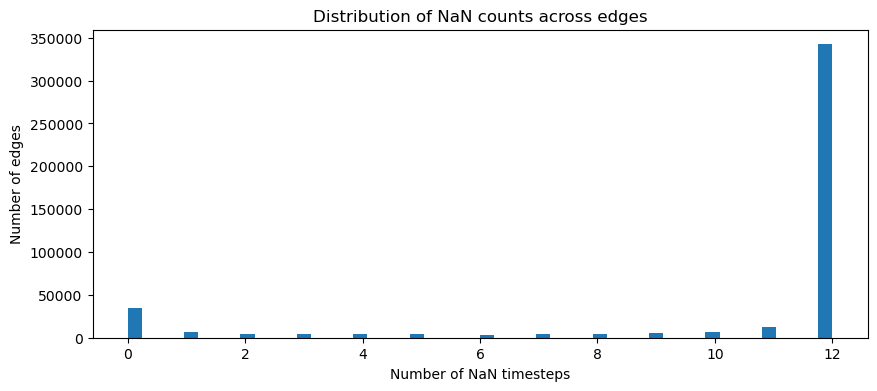

In [53]:
nan_counts = np.sum(np.isnan(data_train.y_avg_speed.cpu().numpy()), axis=1)

plt.figure(figsize=(10, 4))
plt.hist(nan_counts, bins=50)
plt.xlabel("Number of NaN timesteps")
plt.ylabel("Number of edges")
plt.title("Distribution of NaN counts across edges")
plt.show()

In [54]:
# import matplotlib.pyplot as plt
# nan_counts = np.sum(np.isnan(data_train.y_avg_speed.cpu().numpy()), axis=1)
# nan_counts_sorted = np.sort(nan_counts)  # small to high

# plt.figure(figsize=(12, 4))
# plt.bar(x=range(len(nan_counts_sorted)), height=nan_counts_sorted)
# plt.xlabel("Edge (sorted by NaN count)")
# plt.ylabel("Number of NaN timesteps")
# plt.title("NaN counts per edge (sorted)")
# plt.tight_layout()
# plt.show()

In [55]:
valid_avg

tensor([[ True,  True,  True,  ...,  True,  True,  True],
        [ True,  True,  True,  ...,  True,  True,  True],
        [ True,  True,  True,  ...,  True,  True,  True],
        ...,
        [False, False, False,  ...,  True, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]], device='cuda:0')

In [58]:
n = data_train.num_nodes
print(f"num_nodes: {n}")
print(f"edge_index max: {data_train.edge_index.max().item()}")
print(f"edge_index min: {data_train.edge_index.min().item()}")

# This should be True
print(data_train.edge_index.max().item() < n)

print(data_train.x.shape[0])
print(data_train.num_nodes)

# mask = (data_train.edge_index[0] < n) & (data_train.edge_index[1] < n)
# data_train.edge_index = data_train.edge_index[:, mask]
print(f"x_cont shape: {data_train.x_cont.shape[0]}, num_nodes: {n}")

num_nodes: 436042
edge_index max: 436041
edge_index min: 0
True
436042
436042
x_cont shape: 436042, num_nodes: 436042


In [59]:
n = data_val.num_nodes
print(f"num_nodes: {n}")
print(f"edge_index max: {data_val.edge_index.max().item()}")
print(f"edge_index min: {data_val.edge_index.min().item()}")

# This should be True
print(data_val.edge_index.max().item() < n)

print(data_val.x.shape[0])
print(data_val.num_nodes)

# mask = (data_train.edge_index[0] < n) & (data_train.edge_index[1] < n)
# data_train.edge_index = data_train.edge_index[:, mask]
print(f"x_cont shape: {data_val.x_cont.shape[0]}, num_nodes: {n}")

num_nodes: 25650
edge_index max: 25649
edge_index min: 0
True
25650
25650
x_cont shape: 25650, num_nodes: 25650


In [60]:


# =========================
# 9) Corruption + losses + metrics
# =========================
def corrupt_inputs_with_flags(data, masks):
    x_cont = data.x_cont.clone()
    highway_in = data.highway_in.clone()
    nlanes_in = data.nlanes_in.clone()
    oneway_in = data.oneway_in.clone()

    highway_in[masks["hwy"]] = HIGHWAY_MASK_ID
    nlanes_in[masks["lan"]]   = LANES_MASK_ID
    oneway_in[masks["onw"]]  = ONEWAY_MASK_ID

    # reset flags
    x_cont[:, CONT_LENMASK_COL] = 0.0
    x_cont[:, CONT_WIDMASK_COL] = 0.0
    x_cont[:, CONT_MAXMASK_COL] = 0.0
    x_cont[:, CONT_MINMASK_COL] = 0.0
    x_cont[:, CONT_AVGMASK_START:CONT_AVGMASK_END] = 0.0

    # IMPORTANT: we still can mask LENGTH as an *input corruption* channel to regularize

    # If we want length to be masked sometimes as a denoising input, we do it here:
    # Example: mask length whenever width is masked (keeps code structure). You can comment it out.
    # x_cont[masks["wid"], CONT_LENGTH_COL] = 0.0
    # x_cont[masks["wid"], CONT_LENMASK_COL] = 1.0

    x_cont[masks["wid"], CONT_WIDTH_COL]  = 0.0
    x_cont[masks["wid"], CONT_WIDMASK_COL] = 1.0

    x_cont[masks["max"], CONT_MAX_COL] = 0.0
    x_cont[masks["max"], CONT_MAXMASK_COL] = 1.0

    x_cont[masks["min"], CONT_MIN_COL] = 0.0
    x_cont[masks["min"], CONT_MINMASK_COL] = 1.0
    
    # corrupt avg_speed (zero out all 12 slots + set mask flags)
    # x_cont[masks["avg"], CONT_AVG_START:CONT_AVG_END]     = 0.0
    # x_cont[masks["avg"], CONT_AVGMASK_START:CONT_AVGMASK_END] = 1.0
    x_cont[:, CONT_AVG_START:CONT_AVG_END][masks["avg"]]      = 0.0
    x_cont[:, CONT_AVGMASK_START:CONT_AVGMASK_END][masks["avg"]] = 1.0

    return x_cont, highway_in, nlanes_in, oneway_in

def compute_losses(pred, data, masks):
    losses = {}

    losses["hwy"] = loss_ce(pred["highway"][masks["hwy"]], data.y_highway[masks["hwy"]]) if masks["hwy"].any() \
        else torch.tensor(0.0, device=device)

    losses["lan"] = loss_ce(pred["nlanes"][masks["lan"]], data.y_nlanes[masks["lan"]]) if masks["lan"].any() \
        else torch.tensor(0.0, device=device)

    losses["onw"] = loss_bce(pred["oneway"][masks["onw"]], data.y_oneway[masks["onw"]]) if masks["onw"].any() \
        else torch.tensor(0.0, device=device)

    losses["wid"] = loss_huber(pred["width"][masks["wid"]], data.y_width[masks["wid"]]) if masks["wid"].any() \
        else torch.tensor(0.0, device=device)

    losses["max"] = loss_huber(pred["max_speed"][masks["max"]], data.y_max[masks["max"]]) if masks["max"].any() \
        else torch.tensor(0.0, device=device)
    
    losses["min"] = loss_huber(pred["min_speed"][masks["min"]], data.y_min[masks["min"]]) if masks["min"].any() \
        else torch.tensor(0.0, device=device)
        
    # avg_speed: masked Huber ignoring NaN slots within each road
    # if masks["avg"].any():
    #     pred_avg   = pred["avg_speed"][masks["avg"]]       # (k, 12)
    #     target_avg = data.y_avg_speed[masks["avg"]]        # (k, 12)
    #     slot_mask  = ~torch.isnan(target_avg)              # (k, 12) ignore NaN slots
    #     losses["avg"] = loss_huber(pred_avg[slot_mask], target_avg[slot_mask]) \
    #         if slot_mask.any() else torch.tensor(0.0, device=device)
    # else:
    #     losses["avg"] = torch.tensor(0.0, device=device)
    # CHANGE TO — masks["avg"] is already (n,12), use it directly as slot_mask
    if masks["avg"].any():
        losses["avg"] = loss_huber(
            pred["avg_speed"][masks["avg"]],
            data.y_avg_speed[masks["avg"]]
        )
    else:
        losses["avg"] = torch.tensor(0.0, device=device)
    total = model.weighted_sum(losses)
    return total, losses

def macro_f1_from_preds(y_true, y_pred, num_classes):
    f1s = []
    for c in range(num_classes):
        tp = ((y_pred == c) & (y_true == c)).sum().float()
        fp = ((y_pred == c) & (y_true != c)).sum().float()
        fn = ((y_pred != c) & (y_true == c)).sum().float()

        denom_p = tp + fp
        denom_r = tp + fn
        prec = tp / denom_p if denom_p > 0 else torch.tensor(0.0, device=y_true.device)
        rec  = tp / denom_r if denom_r > 0 else torch.tensor(0.0, device=y_true.device)

        denom_f = prec + rec
        f1 = (2 * prec * rec / denom_f) if denom_f > 0 else torch.tensor(0.0, device=y_true.device)
        f1s.append(f1)

    return float(torch.stack(f1s).mean())

def binary_auroc(y_true, scores):
    y_true = y_true.float()
    scores = scores.float()

    n_pos = (y_true == 1).sum().item()
    n_neg = (y_true == 0).sum().item()
    if n_pos == 0 or n_neg == 0:
        return np.nan

    sorted_scores, order = torch.sort(scores)
    ranks = torch.empty_like(order, dtype=torch.float32)
    ranks[order] = torch.arange(1, len(scores) + 1, device=scores.device, dtype=torch.float32)

    diffs = torch.diff(sorted_scores)
    tie_starts = torch.where(diffs != 0)[0] + 1
    boundaries = torch.cat([
        torch.tensor([0], device=scores.device),
        tie_starts,
        torch.tensor([len(scores)], device=scores.device),
    ])

    for i in range(len(boundaries) - 1):
        a = int(boundaries[i].item())
        b = int(boundaries[i + 1].item())
        if b - a > 1:
            avg = (a + 1 + b) / 2.0
            ranks[order[a:b]] = avg

    sum_ranks_pos = ranks[y_true == 1].sum()
    n_pos_t = torch.tensor(float(n_pos), device=scores.device)
    n_neg_t = torch.tensor(float(n_neg), device=scores.device)

    auroc = (sum_ranks_pos - n_pos_t * (n_pos_t + 1) / 2.0) / (n_pos_t * n_neg_t)
    return float(auroc)

def compute_metrics(pred, data, masks, num_highway_classes):
    out = {}

    if masks["hwy"].any():
        y_true = data.y_highway[masks["hwy"]]
        y_pred = pred["highway"][masks["hwy"]].argmax(dim=1)
        out["hwy_macro_f1"] = macro_f1_from_preds(y_true, y_pred, num_highway_classes)
    else:
        out["hwy_macro_f1"] = np.nan

    if masks["lan"].any():
        y_true = data.y_nlanes[masks["lan"]]
        y_pred = pred["nlanes"][masks["lan"]].argmax(dim=1)
        out["lan_macro_f1"] = macro_f1_from_preds(y_true, y_pred, 3)
    else:
        out["lan_macro_f1"] = np.nan

    if masks["onw"].any():
        out["onw_auroc"] = binary_auroc(data.y_oneway[masks["onw"]], pred["oneway"][masks["onw"]])
    else:
        out["onw_auroc"] = np.nan

    out["wid_mae_m"] = float(torch.mean(torch.abs(pred["width"][masks["wid"]] - data.y_width[masks["wid"]]))) \
        if masks["wid"].any() else np.nan
    out["max_mae"] = float(torch.mean(torch.abs(pred["max_speed"][masks["max"]] - data.y_max[masks["max"]]))) \
        if masks["max"].any() else np.nan   
    out["min_mae"] = float(torch.mean(torch.abs(pred["min_speed"][masks["min"]] - data.y_min[masks["min"]]))) \
        if masks["min"].any() else np.nan
    # NOTE: no length metric (length is input-only)
    
    # avg_speed MAE: only over masked roads and non-NaN slots
    # if masks["avg"].any():
    #     pred_avg   = pred["avg_speed"][masks["avg"]]
    #     target_avg = data.y_avg_speed[masks["avg"]]
    #     slot_mask  = ~torch.isnan(target_avg)
    #     out["avg_mae"] = float(torch.mean(torch.abs(pred_avg[slot_mask] - target_avg[slot_mask]))) \
    #         if slot_mask.any() else np.nan
    # else:
    #     out["avg_mae"] = np.nan
    # CHANGE TO
    if masks["avg"].any():
        out["avg_mae"] = float(torch.mean(torch.abs(
            pred["avg_speed"][masks["avg"]] - data.y_avg_speed[masks["avg"]]
        )))
    else:
        out["avg_mae"] = np.nan
    return out

@torch.no_grad()
def evaluate_with_masks(model, data, masks, num_highway_classes):
    model.eval()
    x_cont, highway_in, nlanes_in, oneway_in = corrupt_inputs_with_flags(data, masks)
    pred = model(x_cont, highway_in, nlanes_in, oneway_in, data.edge_index)
    total, losses = compute_losses(pred, data, masks)
    metrics = compute_metrics(pred, data, masks, num_highway_classes)
    return total.item(), {k: v.item() for k, v in losses.items()}, metrics

@torch.no_grad()
def evaluate_losses_only(model, data, masks):
    model.eval()
    x_cont, highway_in, nlanes_in, oneway_in = corrupt_inputs_with_flags(data, masks)
    pred = model(x_cont, highway_in, nlanes_in, oneway_in, data.edge_index)
    total, losses = compute_losses(pred, data, masks)
    return total.item(), {k: v.item() for k, v in losses.items()}

In [61]:
# =========================
# 10) Training loop + logging
# =========================
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 10000
P_MASK = 0.30
EVAL_EVERY = 1

val_masks_fixed = make_fixed_masks(data_val, p_mask=P_MASK, seed=999)

history = {
    "epoch": [],
    "train_total": [],
    "val_total": [],
    "train_losses": {k: [] for k in ["hwy", "lan", "onw", "wid", "max", "min", "avg"]},
    "val_losses":   {k: [] for k in ["hwy", "lan", "onw", "wid", "max", "min", "avg"]},

    "metric_epoch": [],
    "train_metrics": {k: [] for k in ["hwy_macro_f1", "lan_macro_f1", "onw_auroc", "wid_mae_m", "max_mae", "min_mae", "avg_mae"]},
    "val_metrics":   {k: [] for k in ["hwy_macro_f1", "lan_macro_f1", "onw_auroc", "wid_mae_m", "max_mae", "min_mae", "avg_mae"]},

    "log_vars": [],
}

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    n = data_train.num_nodes

    valid_hwy = torch.ones(n, dtype=torch.bool, device=device)
    valid_lan = (data_train.y_nlanes != -1)
    valid_onw = ~torch.isnan(data_train.y_oneway)
    valid_wid = ~torch.isnan(data_train.y_width)
    valid_max = ~torch.isnan(data_train.y_max)
    valid_min = ~torch.isnan(data_train.y_min)
    valid_avg = ~torch.isnan(data_train.y_avg_speed)#.all(dim=1)  # + avg

    train_masks = {
        "hwy": bernoulli_mask(valid_hwy, P_MASK),
        "lan": bernoulli_mask(valid_lan, P_MASK),
        "onw": bernoulli_mask(valid_onw, P_MASK),
        "wid": bernoulli_mask(valid_wid, P_MASK),
        "max": bernoulli_mask(valid_max, P_MASK),
        "min": bernoulli_mask(valid_min, P_MASK),
        "avg": bernoulli_mask(valid_avg, P_MASK),
    }

    x_cont, highway_in, nlanes_in, oneway_in = corrupt_inputs_with_flags(data_train, train_masks)
    # print("x shape:", x_cont.shape)
    # print("edge_index shape:", data_train.edge_index.shape)
    # print("edge min:", data_train.edge_index.min().item())
    # print("edge max:", data_train.edge_index.max().item())
    pred = model(x_cont, highway_in, nlanes_in, oneway_in, data_train.edge_index)
    
    # --- Sanity check pred outputs ---
    for key, tensor in pred.items():
        if torch.isnan(tensor).any():
            print(f"[NaN] pred['{key}']")
        if torch.isinf(tensor).any():
            print(f"[Inf] pred['{key}']")
        # print(f"pred['{key}'] shape={tensor.shape}, range=[{tensor.min().item():.3f}, {tensor.max().item():.3f}]")

    # --- Sanity check targets (most likely cause) ---
    # Replace these with your actual target attribute names
    for attr in ["highway", "lanes", "oneway"]:   # <-- adjust to your Data attributes
        if hasattr(data_train, attr):
            t = getattr(data_train, attr)
            # print(f"data_train.{attr}: min={t.min().item()}, max={t.max().item()}, dtype={t.dtype}")

    total_loss, losses = compute_losses(pred, data_train, train_masks)
    total_loss.backward()
    optimizer.step()

    val_total, val_losses = evaluate_losses_only(model, data_val, val_masks_fixed)

    history["epoch"].append(epoch)
    history["train_total"].append(total_loss.item())
    history["val_total"].append(val_total)

    for k in ["hwy", "lan", "onw", "wid", "max", "min", "avg"]:
        history["train_losses"][k].append(losses[k].item())
        history["val_losses"][k].append(val_losses[k])

    history["log_vars"].append(model.log_vars.detach().cpu().numpy().copy())

    do_metrics = (epoch == 1) or (epoch % EVAL_EVERY == 0)
    if do_metrics:
        train_metrics = compute_metrics(pred, data_train, train_masks, num_highway)
        _, _, val_metrics = evaluate_with_masks(model, data_val, val_masks_fixed, num_highway)

        history["metric_epoch"].append(epoch)
        for k in ["hwy_macro_f1", "lan_macro_f1", "onw_auroc", "wid_mae_m", "max_mae", "min_mae", "avg_mae"]:
            history["train_metrics"][k].append(train_metrics[k])
            history["val_metrics"][k].append(val_metrics[k])

        print(
            f"Epoch {epoch:04d} | total={total_loss.item():.4f} | "
            f"hwy={losses['hwy'].item():.3f}, lan={losses['lan'].item():.3f}, onw={losses['onw'].item():.3f}, "
            f"wid={losses['wid'].item():.3f} max={losses['max'].item():.3f} min={losses['min'].item():.3f}, "
            f"avg={losses["avg"].item():.3f} | "
            f"VAL fixed: hwy_F1={val_metrics['hwy_macro_f1']:.3f}, lan_F1={val_metrics['lan_macro_f1']:.3f}, "
            f"onw_AUROC={val_metrics['onw_auroc']:.3f}, wid_MAE(m)={val_metrics['wid_mae_m']:.3f} "
            f"max_MAE={val_metrics['max_mae']:.3f}, min_MAE={val_metrics['min_mae']:.3f}, "
            f"avg_MAE={val_metrics['avg_mae']:.3f} | "                                             # + avg
            f"log_vars={model.log_vars.detach().cpu().numpy()}"
        )

Epoch 0001 | total=50.1590 | hwy=2.287, lan=1.329, onw=0.730, wid=3.143 max=36.151 min=1.126, avg=5.394 | VAL fixed: hwy_F1=0.001, lan_F1=0.036, onw_AUROC=0.593, wid_MAE(m)=4.075 max_MAE=25.074, min_MAE=0.123, avg_MAE=7.317 | log_vars=[ 0.001  0.001 -0.001  0.001  0.001  0.001  0.001]
Epoch 0002 | total=49.1475 | hwy=2.239, lan=1.282, onw=0.713, wid=3.070 max=35.507 min=1.003, avg=5.376 | VAL fixed: hwy_F1=0.004, lan_F1=0.038, onw_AUROC=0.646, wid_MAE(m)=4.002 max_MAE=25.027, min_MAE=0.122, avg_MAE=7.310 | log_vars=[ 0.00199879  0.00199266 -0.00200109  0.00199889  0.00199944  0.00168079
  0.00199986]
Epoch 0003 | total=49.4784 | hwy=2.193, lan=1.235, onw=0.697, wid=3.000 max=36.041 min=1.027, avg=5.372 | VAL fixed: hwy_F1=0.009, lan_F1=0.043, onw_AUROC=0.692, wid_MAE(m)=3.928 max_MAE=24.979, min_MAE=0.122, avg_MAE=7.302 | log_vars=[ 0.00299551  0.00297125 -0.00300387  0.00299594  0.00299925  0.00232187
  0.0029996 ]
Epoch 0004 | total=49.4612 | hwy=2.146, lan=1.191, onw=0.681, wid=2.91

KeyboardInterrupt: 

In [80]:
device = 'cpu'
data_train = data_train.to(device)
data_val = data_val.to(device)
data_test = data_test.to(device)

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [62]:
train_metrics = compute_metrics(pred, data_train, train_masks, num_highway)
test_masks_fixed = make_fixed_masks(data_test, p_mask=P_MASK, seed=999)
_, _, test_metrics = evaluate_with_masks(model, data_test, test_masks_fixed, num_highway)
_, _, val_metrics = evaluate_with_masks(model, data_val, val_masks_fixed, num_highway)

print(
    f"Epoch {epoch:04d} | total={total_loss.item():.4f} | "
    f"hwy={losses['hwy'].item():.3f}, lan={losses['lan'].item():.3f}, onw={losses['onw'].item():.3f}, "
    f"wid={losses['wid'].item():.3f} max={losses['max'].item():.3f} min={losses['min'].item():.3f} |\n "
    f"VAL fixed: hwy_F1={val_metrics['hwy_macro_f1']:.3f}, lan_F1={val_metrics['lan_macro_f1']:.3f}, "
    f"onw_AUROC={val_metrics['onw_auroc']:.3f}, wid_MAE(m)={val_metrics['wid_mae_m']:.3f} "
    f"max_MAE={val_metrics['max_mae']:.3f}, min_MAE={val_metrics['min_mae']:.3f} |\n "
    f"TEST fixed: hwy_F1={test_metrics['hwy_macro_f1']:.3f}, lan_F1={test_metrics['lan_macro_f1']:.3f}, "
    f"onw_AUROC={test_metrics['onw_auroc']:.3f}, wid_MAE(m)={test_metrics['wid_mae_m']:.3f} "
    f"max_MAE={test_metrics['max_mae']:.3f}, min_MAE={test_metrics['min_mae']:.3f} |\n "
    f"log_vars={model.log_vars.detach().cpu().numpy()}"
        )

Epoch 2398 | total=0.2085 | hwy=0.218, lan=0.179, onw=0.110, wid=0.142 max=3.426 min=0.574 |
 VAL fixed: hwy_F1=0.615, lan_F1=0.860, onw_AUROC=0.978, wid_MAE(m)=0.477 max_MAE=4.927, min_MAE=0.074 |
 TEST fixed: hwy_F1=0.615, lan_F1=0.840, onw_AUROC=0.983, wid_MAE(m)=0.458 max_MAE=2.938, min_MAE=nan |
 log_vars=[-1.5004193  -1.6734434  -2.0185168  -1.7992024   0.6887749  -0.4730414
 -0.24859126]


In [ ]:
data_train

In [63]:
print(torch.cuda.memory_allocated() / 1024**3, "GB allocated")
print(torch.cuda.memory_reserved() / 1024**3, "GB reserved")

0.43177223205566406 GB allocated
6.0703125 GB reserved


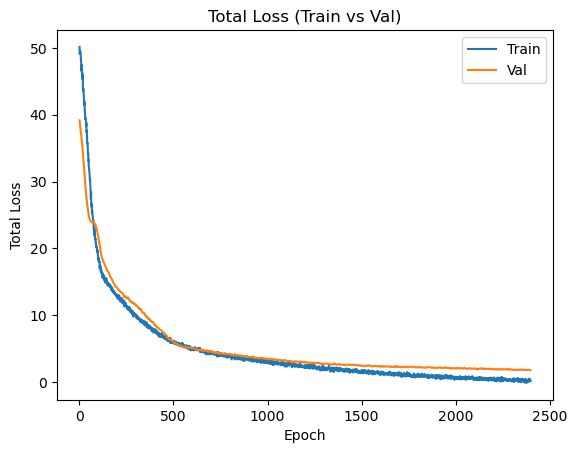

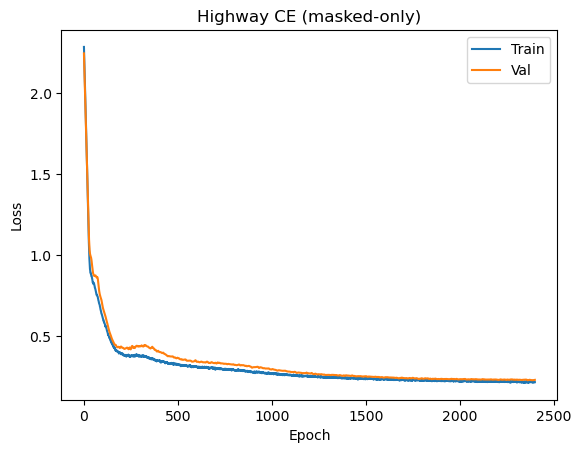

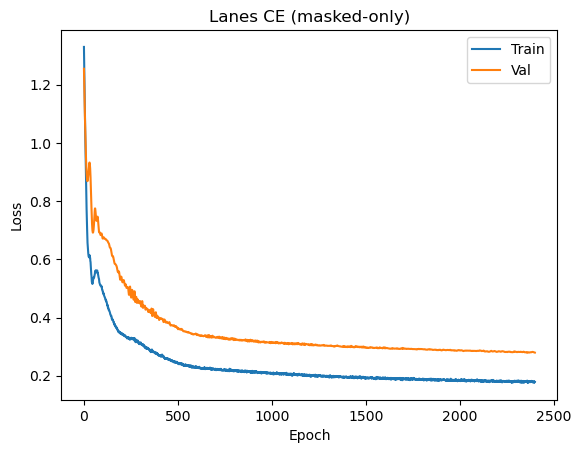

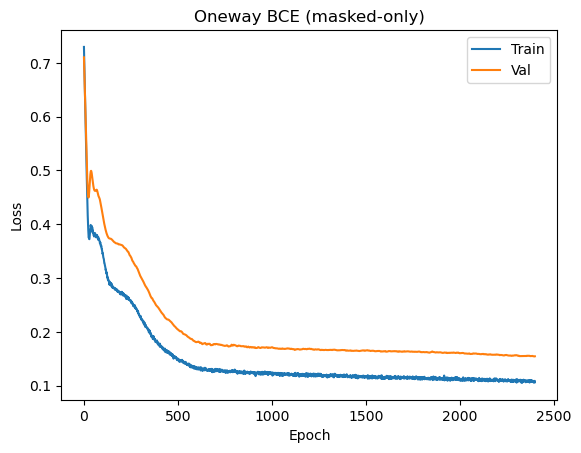

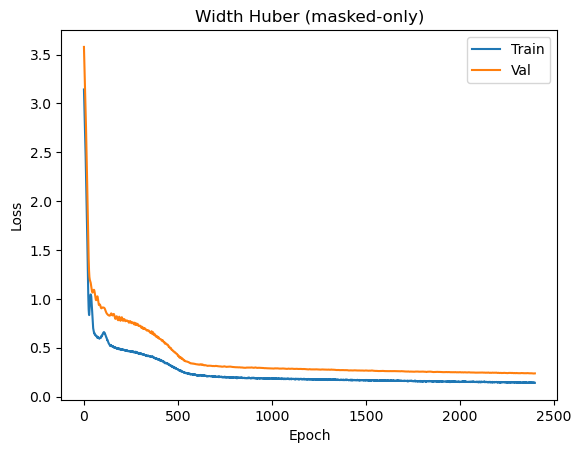

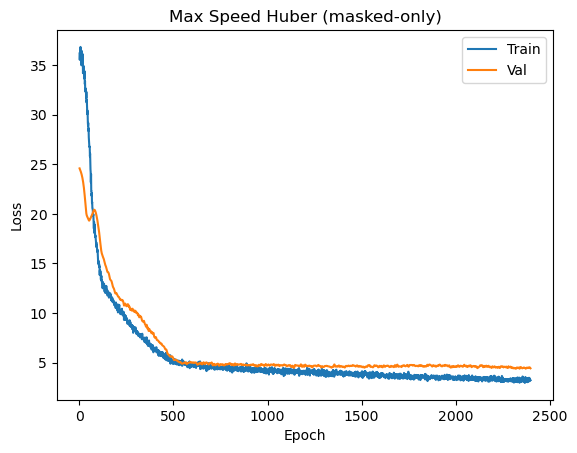

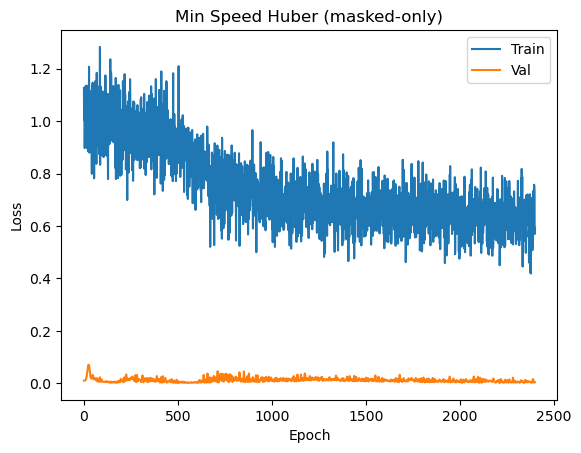

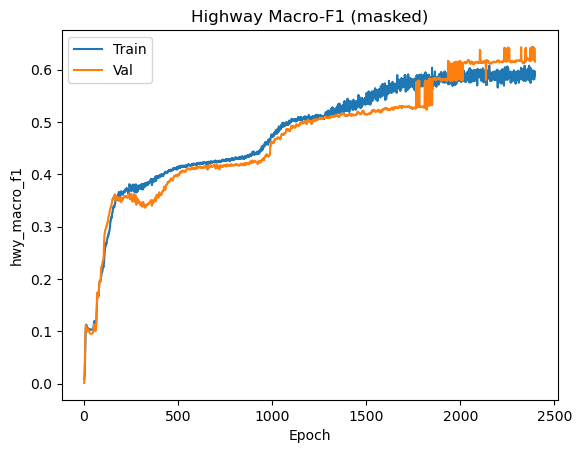

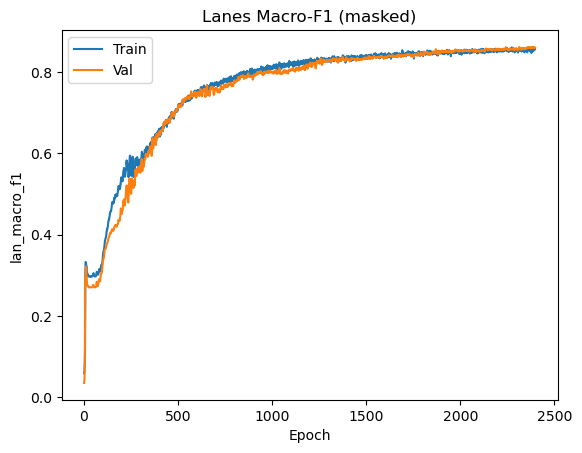

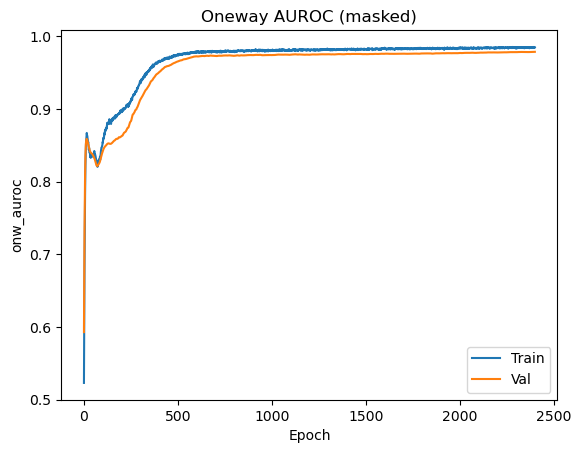

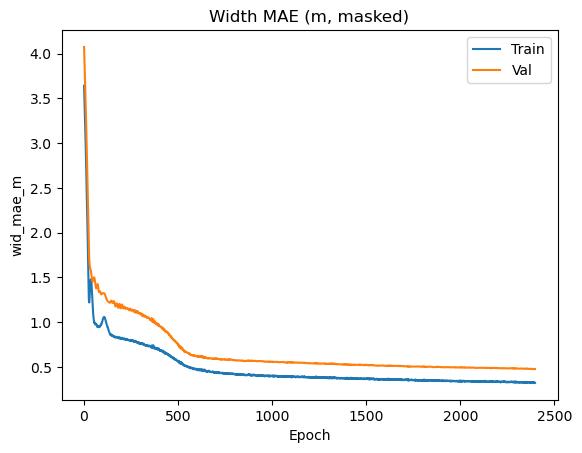

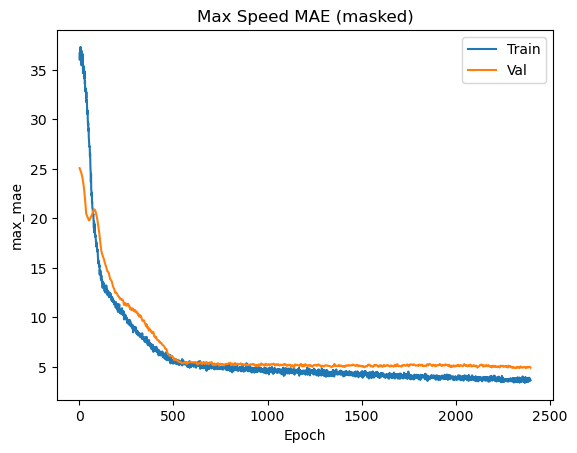

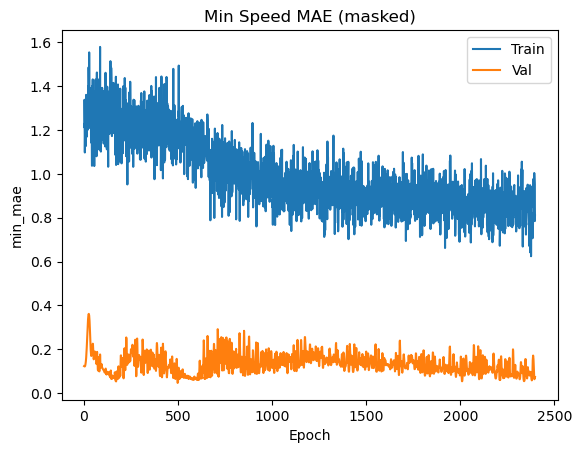

In [64]:
# =========================
# 11) Plots
# =========================
plt.figure()
plt.plot(history["epoch"], history["train_total"], label="Train")
plt.plot(history["epoch"], history["val_total"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Total Loss (Train vs Val)")
plt.legend()
plt.show()

task_titles = {
    "hwy": "Highway CE",
    "lan": "Lanes CE",
    "onw": "Oneway BCE",
    "wid": "Width Huber",
    "max": "Max Speed Huber",
    "min": "Min Speed Huber",
}
for t in ["hwy", "lan", "onw", "wid", "max", "min"]:
    plt.figure()
    plt.plot(history["epoch"], history["train_losses"][t], label="Train")
    plt.plot(history["epoch"], history["val_losses"][t], label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{task_titles[t]} (masked-only)")
    plt.legend()
    plt.show()

metric_titles = {
    "hwy_macro_f1": "Highway Macro-F1 (masked)",
    "lan_macro_f1": "Lanes Macro-F1 (masked)",
    "onw_auroc": "Oneway AUROC (masked)",
    "wid_mae_m": "Width MAE (m, masked)",
    "max_mae": "Max Speed MAE (masked)",
    "min_mae": "Min Speed MAE (masked)",
}
for m in ["hwy_macro_f1", "lan_macro_f1", "onw_auroc", "wid_mae_m", "max_mae", "min_mae"]:
    plt.figure()
    plt.plot(history["metric_epoch"], history["train_metrics"][m], label="Train")
    plt.plot(history["metric_epoch"], history["val_metrics"][m], label="Val")
    plt.xlabel("Epoch")
    plt.ylabel(m)
    plt.title(metric_titles[m])
    plt.legend()
    plt.show()


In [65]:

# =========================
# 12) Final test eval (fixed test masks) on test induced graph
# =========================
test_masks_fixed = make_fixed_masks(data_test, p_mask=P_MASK, seed=2025)
test_total, test_losses, test_metrics = evaluate_with_masks(model, data_test, test_masks_fixed, num_highway)
print("TEST fixed-mask metrics:", test_metrics)
print("TEST fixed-mask losses:", test_losses)

TEST fixed-mask metrics: {'hwy_macro_f1': 0.6315075159072876, 'lan_macro_f1': 0.845160961151123, 'onw_auroc': 0.9861277937889099, 'wid_mae_m': 0.47516173124313354, 'max_mae': 2.630427122116089, 'min_mae': nan, 'avg_mae': 1.6296006441116333}
TEST fixed-mask losses: {'hwy': 0.2244327962398529, 'lan': 0.2802031636238098, 'onw': 0.11165421456098557, 'wid': 0.24394086003303528, 'max': 2.186081647872925, 'min': 0.0, 'avg': 1.2105050086975098}


In [ ]:
# =========================
# CELL X) Save trained model + preprocessing artifacts (for another city)
# =========================


SAVE_DIR = "./checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

ckpt_path = os.path.join(SAVE_DIR, "nyc_gat_multitask.pt")

checkpoint = {
    # model
    "model_state": model.state_dict(),

    # model config needed to recreate the architecture
    "model_cfg": {
        "num_highway": int(num_highway),
        "hwy_emb_dim": 16,
        "nlanes_emb_dim": 8,
        "oneway_emb_dim": 4,
        "cont_dim": 12,
        "hidden": 32,
        "heads": 2,
        "dropout": 0.1,
    },

    # categorical vocab mapping (CRITICAL for cross-city)
    "hwy2id": hwy2id,
    "id2hwy": id2hwy,

    # special token IDs
    "token_ids": {
        "HIGHWAY_MASK_ID": int(HIGHWAY_MASK_ID),
        "LANES_MASK_ID": int(LANES_MASK_ID),
        "LANES_MISS_ID": int(LANES_MISS_ID),
        "ONEWAY_MASK_ID": int(ONEWAY_MASK_ID),
        "ONEWAY_MISS_ID": int(ONEWAY_MISS_ID),
    },

    # scalers (CRITICAL for consistent normalization)
    # All four are fit on the Jakarta training split and MUST be saved —
    # the model expects z-scored length / width / max_speed / min_speed on input.
    "scalers": {
        "len_mu": float(len_scaler.mu),
        "len_sd": float(len_scaler.sd),
        "wid_mu": float(wid_scaler.mu),
        "wid_sd": float(wid_scaler.sd),
        "max_mu": float(max_scaler.mu),
        "max_sd": float(max_scaler.sd),
        "min_mu": float(min_scaler.mu),
        "min_sd": float(min_scaler.sd),
    },

    # metadata (optional)
    "meta": {
        "seed": int(SEED),
        "split_axis": "lon",
        "p_mask": float(P_MASK),
    }
}

torch.save(checkpoint, ckpt_path)
print(f"Saved checkpoint to: {ckpt_path}")

In [ ]:
# TODO: Remember that we have done scaling of the variables so we need to scale back all values to their original scale before inputing it to the database